In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df = pd.read_csv("C:/Users/u461262/OneDrive - WNS/Desktop/Python/Project/Clustering/clustering_data.csv")
df.head()

,feature_1,feature_2,feature_3,feature_4,true_cluster
0,-8.226753,-7.851724,-7.637914,6.666629,1
1,-5.755514,-5.932583,-9.611205,7.730575,1
2,-2.961504,6.590407,3.055976,2.733584,0
3,-2.249315,9.796109,3.402928,0.652713,0
4,-5.883580,-7.636905,-10.260138,8.824857,1


In [6]:
df.shape
df.info()
df.dtypes
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   feature_1     1000 non-null   float64
 1   feature_2     1000 non-null   float64
 2   feature_3     1000 non-null   float64
 3   feature_4     1000 non-null   float64
 4   true_cluster  1000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


,feature_1,feature_2,feature_3,feature_4,true_cluster
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.151306,0.161456,-5.050247,3.117443,1.500000
std,5.149179,6.771608,5.810399,6.147081,1.118593
min,-9.379033,-9.776365,-12.192524,-8.819718,0.000000
25%,-4.644437,-6.335896,-9.152045,-1.249531,0.750000
50%,-0.417746,-0.471332,-7.618550,4.439865,1.500000
75%,4.438441,6.904518,-2.058930,8.375266,2.250000
max,9.891946,12.867018,7.718760,13.324435,3.000000


In [7]:
df.isnull().sum()

feature_1       0
feature_2       0
feature_3       0
feature_4       0
true_cluster    0
dtype: int64

In [8]:
df[df.duplicated()]

,feature_1,feature_2,feature_3,feature_4,true_cluster


In [9]:
features = ['feature_1', 'feature_2', 'feature_3', 'feature_4']
x = df[features]

from sklearn.preprocessing import StandardScaler 
sclaer = StandardScaler ()
x_scale = sclaer.fit_transform(x)

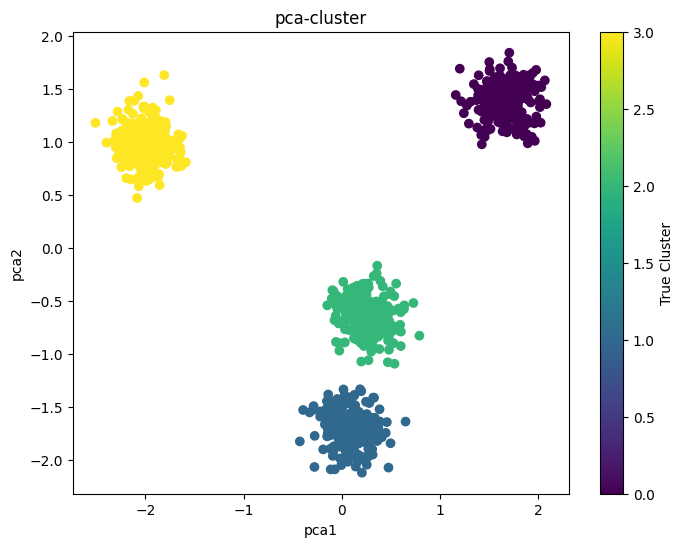

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scale)

plt.figure(figsize = (8,6))
plt.scatter(x_pca[:,0],x_pca[:,1], c = df['true_cluster'])
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.title('pca-cluster')
plt.colorbar(label = 'True Cluster')
plt.show()

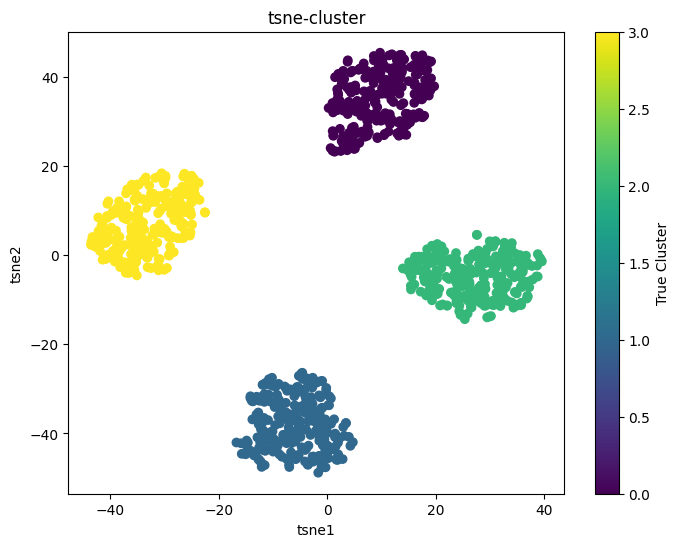

In [11]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2, random_state = 42, perplexity = 30)
x_tsne = tsne.fit_transform(x_scale)

plt.figure(figsize = (8,6))
plt.scatter(x_tsne[:,0],x_tsne[:,1], c = df['true_cluster'])
plt.xlabel('tsne1')
plt.ylabel('tsne2')
plt.title('tsne-cluster')
plt.colorbar(label = 'True Cluster')
plt.show()

(1000, 4)


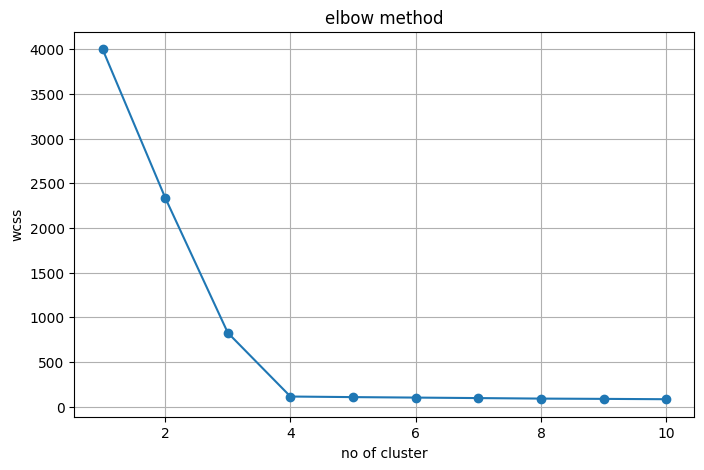

In [12]:
from sklearn.cluster import KMeans
print(x_scale.shape)
wcss = []
for i in range (1,11):
    kmeans = KMeans (n_clusters=i, random_state = 42, n_init=10)
    kmeans.fit(x_scale)
    wcss.append(kmeans.inertia_)

plt.figure(figsize = (8,5))
plt.plot(range(1,11), wcss, marker = 'o')
plt.title('elbow method')
plt.xlabel('no of cluster')
plt.ylabel('wcss')
plt.grid(True)
plt.show()
          

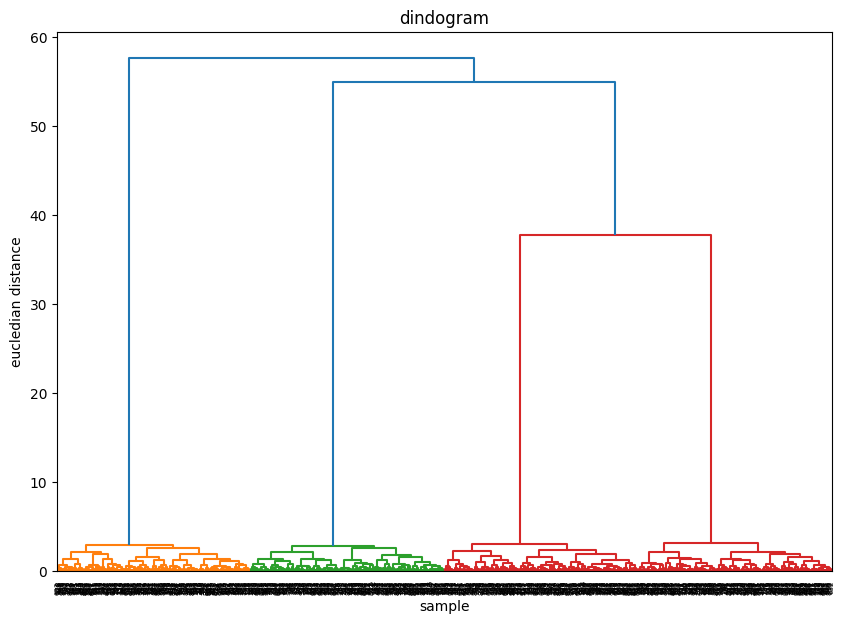

In [13]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize = (10,7))
dendogram = sch.dendrogram(sch.linkage(x_scale, method = 'ward'))
plt.title('dindogram')
plt.xlabel('sample')
plt.ylabel('eucledian distance')
plt.show()

In [14]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
kmeans_cluster = kmeans.fit_predict(x_scale)
df['cluster_kmeans'] = kmeans_cluster

In [15]:
from sklearn.cluster import AgglomerativeClustering
ag = AgglomerativeClustering(n_clusters = 4,  linkage = 'ward')
agcluster = ag.fit_predict(x_scale)
df['ag_cluster'] = agcluster

In [18]:
from sklearn.metrics import silhouette_score

score = silhouette_score (x_scale, kmeans_cluster)
print('silhouette score is', score)

silhouette score is 0.833495118791512


In [19]:
from sklearn.metrics import silhouette_score

score2 = silhouette_score (x_scale, agcluster)
print('silhouette score is', score)

silhouette score is 0.833495118791512


In [24]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score (df['true_cluster'], agcluster)
print('adjusted_rand_score is', ari)

adjusted_rand_score is 1.0


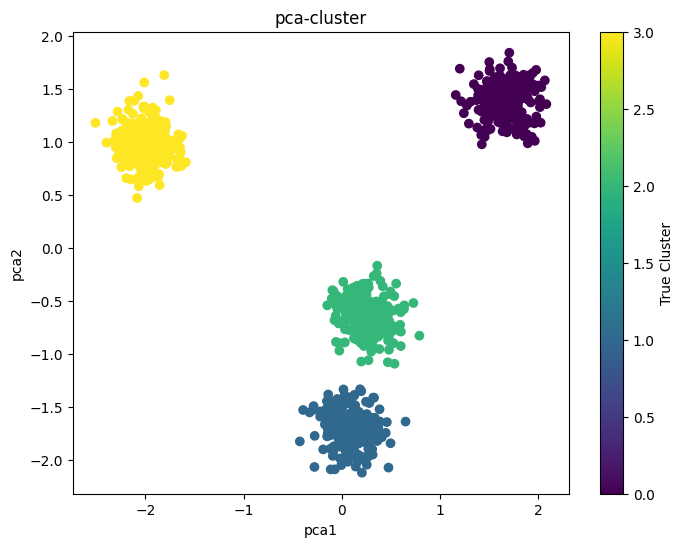

In [20]:

pca = PCA(n_components = 4)
x_pca = pca.fit_transform(x_scale)

plt.figure(figsize = (8,6))
plt.scatter(x_pca[:,0],x_pca[:,1], c = df['true_cluster'])
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.title('pca-cluster')
plt.colorbar(label = 'True Cluster')
plt.show()

In [21]:
df['cluster_kmeans'].value_counts()
df['ag_cluster'].value_counts()

ag_cluster
1    250
2    250
3    250
0    250
Name: count, dtype: int64

In [22]:
df.groupby('cluster_kmeans').mean()
df.groupby('ag_cluster').mean()

,feature_1,feature_2,feature_3,feature_4,true_cluster,cluster_kmeans
ag_cluster,,,,,,
0,1.997095,4.221747,-9.567490,9.381221,2.0,1.0
1,-6.831180,-6.763923,-8.800144,7.357738,1.0,3.0
2,-2.507877,9.030866,4.661212,2.022611,0.0,2.0
3,6.736739,-5.842867,-6.494568,-6.291796,3.0,0.0
